In [1]:
using WaveSpec

Precompiling packages...
   1430.2 ms  ✓ WaveSpec
  1 dependency successfully precompiled in 3 seconds. 209 already precompiled.
[ Info: WaveSpec initialized: Ready for spectral sea state synthesis.


In [2]:
using WaveSpec.ContinuousSpectrums
using WaveSpec.FrequencySampling
using WaveSpec.SpectralSpreading

# 1. Setup
Hs = 3.0
spec = JONSWAP(Hs, 10.0)
nf = 10

# 2. Discretize using the Energy Domain marker
# We use UniformSampling here to get 'Equal Energy' steps
ds = DiscreteSpectrum(spec, UniformSampling(), get_fmin(spec), get_fmax(spec), nf; 
                        domain=FrequencySampling.Energy, mess=false)

# 3. Get amplitudes
amplitudes = get_amplitudes(ds)

#energies = 0.5 * amplitudes .^2

9-element Vector{Float64}:
 0.30726725683891165
 0.37764686052326063
 0.37680713050436593
 0.3763688114461783
 0.3759922649779073
 0.3755192210630063
 0.3744422949488506
 0.3703841666688662
 0.2110835235321218

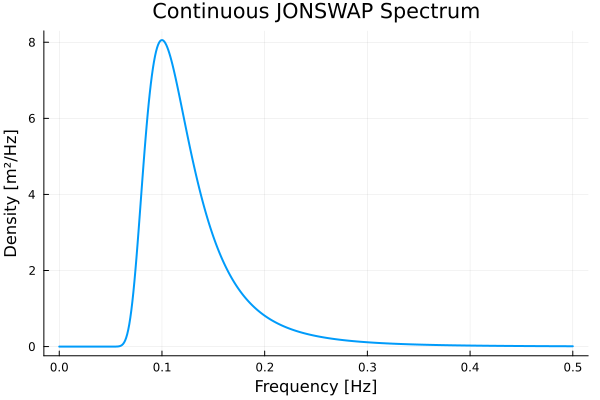

In [3]:
using Plots 

fmin = get_fmin(spec)
fmax = get_fmax(spec)
f_plot = range(fmin, fmax, length=500)

p1 = plot(f_plot, [ContinuousSpectrums.get_density(spec, f) for f in f_plot], title="Continuous JONSWAP Spectrum",
    xlabel="Frequency [Hz]", ylabel="Density [m²/Hz]", linewidth=2, legend=false)


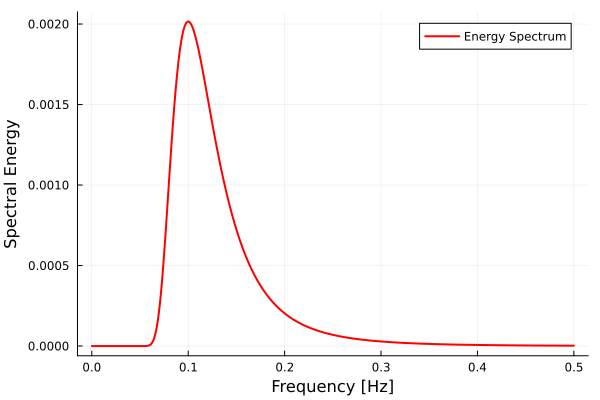

In [30]:
# Calculate the CDF within the [fmin, fmax] range
f_fine = range(fmin, fmax, length=2000)
f_central_fine = (f_fine[1:end-1] + f_fine[2:end]) ./ 2.0
df = diff(f_fine)
S_fine = [ContinuousSpectrums.get_density(spec,f) for f in f_central_fine]

p2 = plot(f_central_fine, S_fine .* df, 
    linecolor=:red, linewidth=2,
    label="Energy Spectrum", xlabel="Frequency [Hz]", ylabel="Spectral Energy")

# plot!(f_central_fine, sqrt.(2 * S_fine .* df), 
#     linecolor=:blue, linewidth=2,
#     label="Spectral Amplitude",
#     xlabel="Frequency [Hz]", ylabel="Spectral Energy")

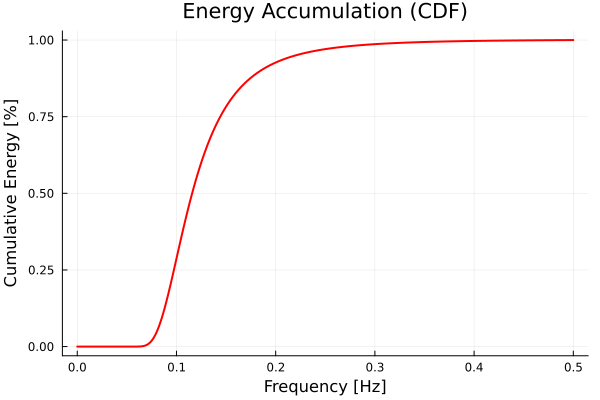

In [31]:
cdf_vals = vcat(0.0, cumsum(S_fine .* df))
cdf_norm = cdf_vals ./ cdf_vals[end]

p3 = plot(f_fine, cdf_norm, 
    linecolor=:red, linewidth=2,
    label="Normalized CDF", title="Energy Accumulation (CDF)",
    xlabel="Frequency [Hz]", ylabel="Cumulative Energy [%]", legend=false)

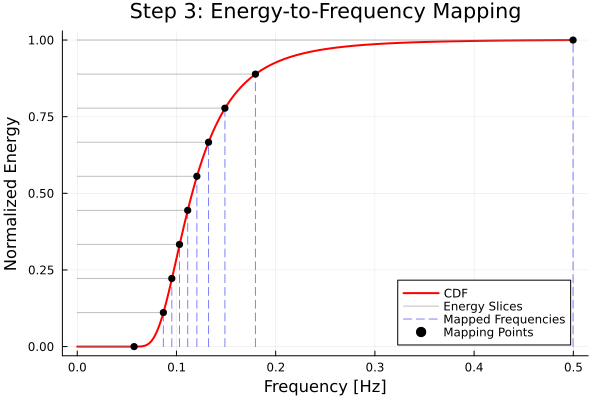

In [81]:
# Uniform sampling in energy domain <=> frequency bins containing equal energy 

# 1. Define uniform target energy levels (e.g., 10 bins)
nf = 10
Ei_norm = collect(range(1.0e-5, 1.0, length=nf)) 

# 2. Map these to frequencies using your inverse CDF function
# (Using the f_fine and cdf_norm from Step 2)

function approx_inverse_cdf(cdf, f_fine, Ei, nf)
    f_target = zeros(nf)

    for (i, E_target) in enumerate(Ei)

        # Binary Search
        idx = searchsortedfirst(cdf, E_target)
        
        # # Linear Interpolation
        # p0, p1 = cdf[idx-1], cdf[idx]
        # f0, f1 = f_fine[idx-1], f_fine[idx]
    
        # f_target[i] = f0 + (E_target - p0) * (f1 - f0) / (p1 - p0)
        f_target[i] = f_fine[idx-1]
    end

    return f_target
end

mapped_freqs = approx_inverse_cdf(cdf_norm, f_fine, Ei_norm, nf)

# 3. Create the Visualization
p4 = plot(f_fine, cdf_norm, label="CDF", color=:red, lw=2, legend=:bottomright,
          title="Step 3: Energy-to-Frequency Mapping",
          xlabel="Frequency [Hz]", ylabel="Normalized Energy")

for (i, p_val) in enumerate(Ei_norm)
    f_val = mapped_freqs[i]
    
    # Draw horizontal projection
    plot!([fmin, f_val], [p_val, p_val], color=:gray, alpha=0.5, label=i==1 ? "Energy Slices" : "")
    # Draw vertical projection
    plot!([f_val, f_val], [0, p_val], color=:blue, style=:dash, alpha=0.5, label=i==1 ? "Mapped Frequencies" : "")
end

# Add markers at the mapping points
scatter!(mapped_freqs, Ei_norm, color=:black, markersize=4, label="Mapping Points")


In [82]:
mapped_freqs, Ei_norm

([0.05728749374687344, 0.08680166083041521, 0.09530574287143571, 0.10305946473236618, 0.11131342671335667, 0.12056786893446723, 0.13232351175587795, 0.14883143571785892, 0.17959620310155078, 0.49974987993997], [1.0e-5, 0.11112, 0.22223, 0.33334, 0.44445, 0.55556, 0.66667, 0.77778, 0.88889, 1.0])

In [83]:
# Calculate midpoints for sampling density
f_centers = (mapped_freqs[1:end-1] .+ mapped_freqs[2:end]) ./ 2.0
dfs = diff(mapped_freqs)
S_sampled = [ContinuousSpectrums.get_density(spec, f) for f in f_centers]

amplitudes_not_normalised = sqrt.(2 * S_sampled .* dfs)

9-element Vector{Float64}:
 0.28743675936813967
 0.35216378606490256
 0.35337524574499524
 0.35678436631421767
 0.35272071156059603
 0.3541968790460411
 0.3504428453615597
 0.3493319526293675
 0.19863258399575823

In [84]:
# 4. Compute moments with discretization error
m₀ = sum(S_sampled .* dfs)

# 5. Normalization factor (Energy Preservation)
norm_factor = (Hs / (4.0 * sqrt(m₀)))^2

# Normalise samples
densities = S_sampled * norm_factor

# The "Energy" of each discrete component
amplitudes = sqrt.(2 * densities .* dfs) 


9-element Vector{Float64}:
 0.30594947825430086
 0.3748453289115354
 0.3761348141460101
 0.3797635033288148
 0.37543812388044784
 0.37700936575285376
 0.3730135489003365
 0.3718311077520372
 0.2114257604747471

In [85]:
# Compute cdf with mapped frequencies to see if they match energy samples
f_central_mapped = (mapped_freqs[1:end-1] + mapped_freqs[2:end]) ./ 2.0
df = diff(mapped_freqs)
S_mapped = [ContinuousSpectrums.get_density(spec,f) for f in f_central_mapped]

cdf_mapped = vcat(0.0, cumsum(S_mapped .* df))
cdf_mapped_norm = cdf_mapped ./ cdf_mapped[end]


10-element Vector{Float64}:
 0.0
 0.08320451843918127
 0.20810142564522321
 0.3338591131231375
 0.4620549517547596
 0.5873472049662
 0.7136903710687502
 0.8373695778805047
 0.9602659091623776
 1.0

In [86]:
Ei_norm

10-element Vector{Float64}:
 1.0e-5
 0.11112
 0.22223
 0.33334
 0.44445
 0.55556
 0.66667
 0.77778
 0.88889
 1.0